In [1]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load training data

X_train = pd.read_csv("../data/X_train.csv")
y_train = pd.read_csv("../data/y_train.csv")

In [4]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (4930, 30)
y_train shape: (4930, 1)


In [5]:
# Combine features + target
df_train = X_train.copy()
df_train["Churn"] = y_train

# Check
df_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,0,0,0,5,1,0,80.20,384.25,0,...,0,1,0,0,0,0,0,1,0,0
1,0,1,0,0,3,1,1,86.85,220.95,0,...,0,1,0,0,0,0,0,1,0,1
2,0,0,1,0,3,1,1,75.15,216.75,0,...,0,0,0,0,0,0,1,0,0,1
3,0,0,0,0,60,1,0,80.55,4847.05,0,...,0,1,0,1,1,0,1,0,0,0
4,0,0,0,0,12,1,1,98.90,1120.95,0,...,0,1,0,1,0,0,0,0,0,1


In [6]:
# Correlation matrix
corr_matrix = df_train.corr()

# Correlation with target variable
churn_corr = corr_matrix["Churn"].sort_values(ascending=False)

print(churn_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.308472
PaymentMethod_Electronic check           0.307645
PaperlessBilling                         0.204078
MonthlyCharges                           0.199737
SeniorCitizen                            0.144162
StreamingTV_Yes                          0.069610
StreamingMovies_Yes                      0.067464
MultipleLines_Yes                        0.046762
PhoneService                             0.023820
gender                                   0.005101
MultipleLines_No phone service          -0.023820
DeviceProtection_Yes                    -0.059625
OnlineBackup_Yes                        -0.082264
PaymentMethod_Mailed check              -0.086483
PaymentMethod_Credit card (automatic)   -0.140672
Partner                                 -0.150181
TechSupport_Yes                         -0.163285
OnlineSecurity_Yes                      -0.170886
Dependents                              -0.172057


In [8]:
#important faetures

important_features = churn_corr[abs(churn_corr) > 0.10].drop("Churn")

print("Important Features (cleaned):")
print(important_features)

Important Features (cleaned):
InternetService_Fiber optic              0.308472
PaymentMethod_Electronic check           0.307645
PaperlessBilling                         0.204078
MonthlyCharges                           0.199737
SeniorCitizen                            0.144162
PaymentMethod_Credit card (automatic)   -0.140672
Partner                                 -0.150181
TechSupport_Yes                         -0.163285
OnlineSecurity_Yes                      -0.170886
Dependents                              -0.172057
Contract_One year                       -0.182066
TotalCharges                            -0.190210
InternetService_No                      -0.233487
StreamingTV_No internet service         -0.233487
OnlineSecurity_No internet service      -0.233487
OnlineBackup_No internet service        -0.233487
DeviceProtection_No internet service    -0.233487
StreamingMovies_No internet service     -0.233487
TechSupport_No internet service         -0.233487
Contract_Two year   

In [9]:
weak_features = churn_corr[abs(churn_corr) < 0.05].index.tolist()

# remove target if accidentally included
if "Churn" in weak_features:
    weak_features.remove("Churn")

print("Weak Features:")
print(weak_features)

Weak Features:
['MultipleLines_Yes', 'PhoneService', 'gender', 'MultipleLines_No phone service']


In [10]:
X_train_reduced = X_train.drop(columns=weak_features)

print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_reduced.shape)
print("Removed features:", weak_features)

Original shape: (4930, 30)
Reduced shape: (4930, 26)
Removed features: ['MultipleLines_Yes', 'PhoneService', 'gender', 'MultipleLines_No phone service']


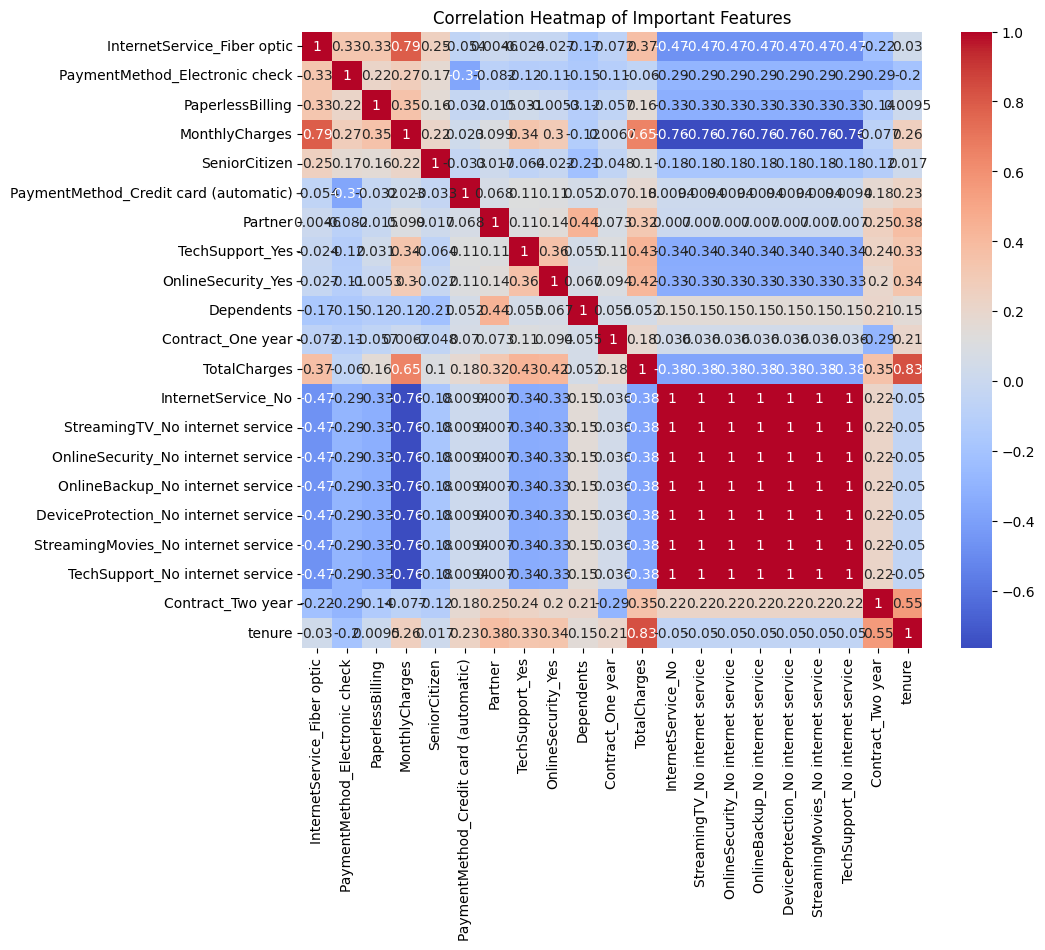

In [11]:
selected_features = important_features.index.tolist()

# remove Churn if still inside
if "Churn" in selected_features:
    selected_features.remove("Churn")

plt.figure(figsize=(10,8))

sns.heatmap(
    df_train[selected_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Important Features")
plt.show()